# Analyze data

A notebook to analyze the correlations between PM6 (or DFT)-level descriptors of Michael Acceptors and their PM6 (or DFT)-level activation barriers. The barrier values contained in `aza_michael_barriers_pm6.csv` are from the paper ["Reformulating Reactivity Design for Data-Efficient Machine Learning"](https://pubs.acs.org/doi/full/10.1021/acscatal.3c02513) (Lewis-Atwell et al., _ACS Catalysis_, __2023__, 13, 13506-13515). Molecular features are taken from ["Machine learning and semi-empirical calculations: a synergistic approach to rapid, accurate, and mechanism-based reaction barrier prediction"](https://pubs.rsc.org/en/content/articlelanding/2022/sc/d2sc02925a) (Farrar et al., _Chemical Science_, __2022__, 13, 7594-7603), collected into HDF5 format with thanks, by `Niamh Lamin`.

In [1]:
import os
import h5py
from tqdm import tqdm
import numpy as np
import pandas as pd
from rdkit import Chem
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


## Load the initial dataframe
Load main dataframe prepared before (contains Michael acceptor SMILES, indexes, and barrier energies)

In [2]:
# Main dataframe
df = pd.read_csv("aza_michael_barriers_pm6.csv")
df.head()

,Idx,Electrophile,azo_rxn,nitro_rxn,mal_rxn,R1,R2,R3,R4,low_barrier,barrier
0,0,O=C(C(Cl)=C(Cl)Cl)c1ccccc1,1000,256,256,Cl,Cl,Cl,Ph,3.902441,26.524552
1,1,COC(=O)/C(C)=C(\C)c1ccccc1,100,607,607,Ph,Me,Me,OMe,15.713303,33.789782
2,2,CNC(=O)/C(C)=C(\C)c1ccccc1,101,604,604,Ph,Me,Me,NHMe,18.700844,37.891141
3,3,CC(=O)C=C(c1ccccc1)c1ccccc1,10,753,753,Ph,Ph,H,Me,22.678586,32.345897
4,4,C/C(C(=O)N(C)C)=C(/C)c1ccccc1,102,606,606,Ph,Me,Me,NMe2,20.006678,49.757850


## Load the atom-index dataframe

Load dataframe for performing atom-index mapping. Each atom will be associated with an index, which allows you to extract the atom-level (as opposed to global molecule-level) features. The figure below shows a diagram of the substituents on a Michael acceptor in an aza-Michael reaction (taken from ["Reformulating Reactivity Design for Data-Efficient Machine Learning"](https://pubs.acs.org/doi/full/10.1021/acscatal.3c02513)).

<div align="middle">
<img src="aza_Michael.jpg" width="800"/>
</div>

The figure below shows a diagram of the Michael acceptor and transition state for a nitro-Michael reaction (taken from ["Machine learning and semi-empirical calculations: a synergistic approach to rapid, accurate, and mechanism-based reaction barrier prediction"](https://pubs.rsc.org/en/content/articlelanding/2022/sc/d2sc02925a)). Because the Michael acceptor features were extracted from the nitro-Michael dataset, we use the core atom numbering outlined in this diagram. O4: carbonyl oxygen (O), C3: carbonyl carbon (C), C2: $\alpha$-carbon (CA), C1: $\beta$-carbon (CB).

<div align="middle">
<img src="nitro_Michael.PNG" width="600"/>
</div>

In [3]:
# Atom mapping for core Michael acceptor atoms
# (nitro-Michael to match source of features)
# CB = C1, CA = C2, C = C3, O = O4
core_nitro_michael ={
    "O4": 4, "C3": 3, "C2": 2, "C1": 1
}

Getting the atom-mapping for the atoms in the substituents is more complicated, because it differs between datasets and between molecules in the same dataset. To do this, we use a CSV file prepared already to map between substituent identifiers and their first atom (nearest to the Michael acceptor).

In [4]:
# Dataframe for mapping molecule substituent indices
df_idx = pd.read_csv("Substituent_Indices/subst_indices_nma_gs.csv")
# the column "nitro_rxn" gives the molecule-level index of this entry (for the nitro-Michael dataset)
df_idx["nitro_rxn"] = df_idx["structure"].apply(lambda x: int(x.split("-")[-1]))
df_idx.head() 

,structure,R1,R2,R3,R4,nitro_rxn
0,gs-1,5,6,7,8,1
1,gs-10,5,6,7,8,10
2,gs-100,5,6,7,8,100
3,gs-1000,5,6,7,8,1000
4,gs-101,5,6,7,8,101


## Load the HDF5 file of features

We now load the HDF5 file containing all the molecule-level and atom-level descriptors, using the [H5PY](https://docs.h5py.org/en/stable/) package. HDF5 (or H5) file formats can contain the equivalent of multiple different tables of data, and are constructed as nested dictionaries, with key-value pairings. It is not always clear which keys are available to a HDF5 file until it is read, and it is useful to print them all out to see what is available.

In [5]:
# Source of molecular/atomic features (nitro-Michael PM6)
# with h5py.File("nitro_ma_gs/nitro_ma_gs_pm6.hdf5", "r") as f: 
with h5py.File("nitro_ma_gs/nitro_ma_gs_pm6.hdf5", "r") as f: 
    keys = f.keys()
    keylist = list(keys)
    # Try printing the set of available features
    # and also the level-of-theory they are available at
    for i in range(len(keylist)):
        print(keylist[i])
        print(list(f[keylist[i]]))

atomic_MRs
['PM6']
atomic_acharges
['PM6']
atomic_acharges_sum
['PM6']
atomic_aromatics
['PM6']
atomic_d4_coord_nums_multi
['PM6']
atomic_d4_coord_nums_single
['PM6']
atomic_estates
['PM6']
atomic_fcharges
['PM6']
atomic_heavies
['PM6']
atomic_hybridizations
['PM6']
atomic_hydrogens
['PM6']
atomic_logPs
['PM6']
atomic_mcharges
['PM6']
atomic_mcharges_sum
['PM6']
atomic_nums
['DFT', 'PM6']
atomic_pbvs
['PM6']
atomic_pcharges
['PM6']
atomic_pints
['PM6']
atomic_rings
['PM6']
atomic_sasas
['PM6']
atomic_sterimol_B1s
['PM6']
atomic_sterimol_B5s
['PM6']
atomic_sterimol_Ls
['PM6']
atomic_valences
['PM6']
atomic_vsas
['PM6']
cartesians
['DFT', 'PM6']
connectivity
['DFT', 'PM6']
energies
['DFT', 'PM6']
files
['DFT', 'PM6']
homo_energies
['PM6']
lumo_energies
['PM6']
num_atoms
['DFT', 'PM6']
num_bonds
['DFT', 'PM6']
one_hots
['DFT', 'PM6']


Here is a compiled list of all available keys in this HDF5 file, split into different types.

In [6]:
# keys: all features available in HDF5 file
# atomic_scalars: scalar values for each atom (e.g. Mulliken charges)
# atomic_arrays: array values for each atom (notably, sterimol parameters)
# scalars: molecule-level scalars (e.g. num_atoms)
# not_implemented: missing from hdf5
# other: file specification (bytes-like strings)

keys =  ['atomic_MRs', 'atomic_acharges', 'atomic_acharges_sum', 
         'atomic_aromatics', 'atomic_d4_coord_nums_multi', 'atomic_d4_coord_nums_single', 
         'atomic_estates', 'atomic_fcharges', 'atomic_heavies', 'atomic_hybridizations', 
         'atomic_hydrogens', 'atomic_logPs', 'atomic_mcharges', 'atomic_mcharges_sum', 
         'atomic_nums', 'atomic_pbvs', 'atomic_pcharges', 'atomic_pints', 'atomic_rings', 
         'atomic_sasas', 'atomic_sterimol_B1s', 'atomic_sterimol_B5s', 'atomic_sterimol_Ls', 
         'atomic_valences', 'atomic_vsas', 'cartesians', 'connectivity', 'energies', 'files', 
         'homo_energies', 'lumo_energies', 'num_atoms', 'num_bonds', 'one_hots']

atomic_scalars = ['atomic_MRs','atomic_aromatics','atomic_d4_coord_nums_multi',
                'atomic_estates','atomic_fcharges','atomic_heavies',
                'atomic_hybridizations','atomic_hydrogens','atomic_logPs',
                'atomic_mcharges','atomic_mcharges_sum',
                'atomic_pbvs','atomic_pcharges','atomic_pints','atomic_rings',
                'atomic_sasas','atomic_valences','atomic_vsas',
                'atomic_nums'
                ]

atomic_arrays = ['atomic_sterimol_B1s','atomic_sterimol_B5s','atomic_sterimol_Ls','cartesians','connectivity','one_hots']

scalars = ['energies','homo_energies','lumo_energies','num_atoms','num_bonds']

not_implemented = ['atomic_acharges','atomic_acharges_sum']

other = ['files']

These features are derived from a range of sources, including RDKit, Morpheus and Gaussian (via CCLIB). This table is taken from ["Machine learning and semi-empirical calculations: a synergistic approach to rapid, accurate, and mechanism-based reaction barrier prediction"](https://pubs.rsc.org/en/content/articlelanding/2022/sc/d2sc02925a) and gives a brief description of each feature. 

(N.B. not all features in this table are available here in this HDF5 file).

<div align="middle">
<img src="features.PNG" width="800"/>
</div>

Here is a small dictionary to convert from recognisable feature names into their HDF5 key values

In [7]:
# Convert recognisable names into hdf5 keys
# Use one of these names to choose features from above
name_conversion = {
    "Mulliken": "atomic_mcharges",
    "PEOE": "atomic_vsas",
    "Pint": "atomic_pints",
    "PBV": "atomic_pbvs",
    "B1": "atomic_sterimol_B1s",
    "B5": "atomic_sterimol_B5s",
    "Energy": 'energies',
    "HOMO": 'homo_energies',
    "LUMO": 'lumo_energies',
    "NAtoms": 'num_atoms',
    "NBonds": 'num_bonds'
}

## Analyze the feature sets

Process the data and plot a scatter plot of the feature against the reaction barrier energy. 

This code will take the feature (`feat`) and atom (`atom`) chosen by the user, and search the HDF5 file for the corresponding data, creating a new column in the main dataframe (`df`). It will also plot a scatter plot of this feature against the property of interest (`target`), and report a Pearson's $R^2$ statistic of linear correlation. 

Edit the `feat`, `atom`, and `target` to use as you see fit. Feel free to save the plots produced, and even the whole dataframe as a new CSV file with the new columns of collected data.

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


Index: 176
['PM6']
Data: [-1.046549869023]
Index: 566
['PM6']
Data: [0.11673684186450001]
Index: 563
['PM6']
Data: [0.1564654640375]
Index: 728
['PM6']
Data: [-0.389122806215]
Index: 565
['PM6']
Data: [0.167622131908]
Index: 564
['PM6']
Data: [-0.0013605692525000001]
Index: 567
['PM6']
Data: [-0.539329651691]
Index: 578
['PM6']
Data: [-0.7238228423299999]
Index: 577
['PM6']
Data: [-0.513750949744]
Index: 579
['PM6']
Data: [-0.461505090448]
Index: 584
['PM6']
Data: [-0.5401459932425]
Index: 581
['PM6']
Data: [-0.38041516299899997]
Index: 583
['PM6']
Data: [-0.29388295854]
Index: 582
['PM6']
Data: [-0.6386512071235001]
Index: 730
['PM6']
Data: [-0.5289893253719999]
Index: 585
['PM6']
Data: [-0.7371564210045]
Index: 570
['PM6']
Data: [-0.7790619539815]
Index: 568
['PM6']
Data: [-0.5804188431164999]
Index: 571
['PM6']
Data: [-0.452797447232]
Index: 575
['PM6']
Data: [-0.6440934841335]
Index: 572
['PM6']
Data: [-0.309665561869]
Index: 574
['PM6']
Data: [-0.2511610840115]
Index: 573
['PM6']


,Idx,Electrophile,azo_rxn,nitro_rxn,mal_rxn,R1,R2,R3,R4,low_barrier,barrier,Mulliken_O4,PBV_C1,LUMO
0,0,O=C(C(Cl)=C(Cl)Cl)c1ccccc1,1000,256,256,Cl,Cl,Cl,Ph,3.902441,26.524552,-0.420045,90.436238,-1.046550
1,1,COC(=O)/C(C)=C(\C)c1ccccc1,100,607,607,Ph,Me,Me,OMe,15.713303,33.789782,-0.510413,107.288899,0.116737
2,2,CNC(=O)/C(C)=C(\C)c1ccccc1,101,604,604,Ph,Me,Me,NHMe,18.700844,37.891141,-0.550762,108.184194,0.156465
3,3,CC(=O)C=C(c1ccccc1)c1ccccc1,10,753,753,Ph,Ph,H,Me,22.678586,32.345897,-0.487745,114.706455,-0.389123
4,4,C/C(C(=O)N(C)C)=C(/C)c1ccccc1,102,606,606,Ph,Me,Me,NMe2,20.006678,49.757850,-0.562652,112.922142,0.167622


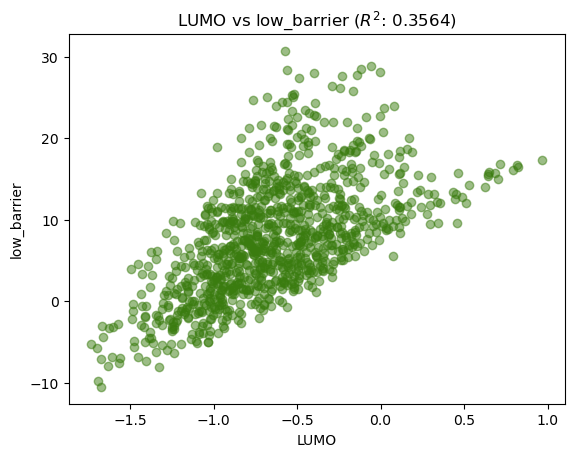

In [10]:
# Select a feature (and an atom type for atom-level features)
# create a new column in the dataframe corresponding to this feature
# O4: carbonyl-O
# C3: carbonyl-C 
# C2: alpha-C
# C1: beta-C
# R4: first atom of substitent bonded to carbonyl
# R3: first atom of substituent bonded to alpha-C
# R2: first atom of substituent bonded to beta-C (cis to carbonyl)
# R1: first atom of substituent bonded to beta-C (trans to carbonyl)

feat = "LUMO"
atom = "C1" # (ignored for non-atomic features)

target = "low_barrier" # target for correlation ("low_barrier" or "barrier")

if feat in name_conversion.keys(): fname = name_conversion[feat]
else: fname = feat

dlist = []
base = [i for i in range(1,1001)] # convert unix to base-1 ordering
unix = sorted(base, key = lambda x: str(x))
with h5py.File("nitro_ma_gs/nitro_ma_gs_pm6.hdf5", "r") as f:

    for index, row in df.iterrows():

        i = row["nitro_rxn"] # 1-indexed
        i = unix.index(i)+1 # convert to unix ordering
        print(f"Index: {i}")

        if fname in atomic_scalars + atomic_arrays:
            if atom in core_nitro_michael.keys(): idx = core_nitro_michael[atom]
            elif atom in df_idx.columns[1:5]: idx = df_idx[df_idx["nitro_rxn"]==i][atom].values[0]
            else: raise ValueError(f"{atom} is an invalid atom specifier")
        
        print(list(f[fname]))
        if "PM6" in list(f[fname]): subkey = "PM6"
        else: subkey = list(f[fname])[0]
        data = (f[fname][subkey])
        if data.shape != (0,):
            if hasattr(data[i-1], "shape"):
                if data[i-1].shape:
                    if fname in atomic_scalars:
                        print(f"Data[{idx-1}]: \n{data[i-1][idx-1]}")
                        dlist.append(data[i-1][idx-1])
                    elif fname in atomic_arrays:
                        if fname == "atomic_sterimol_B1s":
                            array = data[i-1][idx-1].flatten()
                            array = array[np.nonzero(array)]
                            b1 = min(array) if array.any() else 0
                            print(f"min(Data[{idx-1}]): \n{b1}")
                            dlist.append(b1)
                        elif fname == "atomic_sterimol_B5s":
                            array = data[i-1][idx-1].flatten()
                            array = array[np.nonzero(array)]
                            b5 = max(array) if array.any() else 0
                            print(f"max(Data[{idx-1}]): \n{b5}")
                            dlist.append(b5)
                        else: raise ValueError(f"{fname} not implemented yet")
                    elif fname in scalars: 
                        print(f"Data: {data[i-1]}")
                        dlist.append(data[i-1])
                    else: raise ValueError(f"{fname} not implemented yet")
                else: 
                    print(f"Data: {[data[i-1]]}")
                    dlist.append([data[i-1]])
            else: 
                print(f"Data: {data[i-1].decode('utf-8')}")
                dlist.append([data[i-1].decode('utf-8')])
        else: raise ValueError("Empty data, shape: (0,)")

if fname in atomic_scalars + atomic_arrays: colname = "_".join((feat,atom))
else: colname = feat
df[colname] = np.array(dlist).flatten()

# Plot scatter plot of the feature of interest and print Pearson's R^2
R2=np.round(pearsonr(df[colname],df[target]).statistic**2,4)
np.random.seed(int(str(int.from_bytes(colname.encode(),'little'))[:9]))
plt.scatter(df[colname],df[target], c=(np.random.random(),np.random.random(),np.random.random()), alpha=0.5)
plt.xlabel(colname)
plt.ylabel(target)
plt.title(f"{colname} vs {target} ($R^2$: {R2})")
# Display column in DataFrame
df.head()


In [11]:
df.to_csv("Aza_Michael_data.csv", index=False)